* Almost all pixels diverge after the full 1000 iterations, only 0.3% of the pixels maintain agreement between the two precisions
* Most low divergence counts are seen in points that escape the boundary quickly and probably go to infinity at different rates due to the difference precisions. Otherwise, pixels near the boundaries where rounding errors are amplified. Only what seems to be 'central' parts of the set end up going to high iteration counts before they diverge.
* Well, no. As mentioned in (2) the earliest divergence is observed in pixels with low escape counts as well. But this should be due that when z exceeds 2 and the pixels begin going to infinity they do so differently for 32 and 64 bit precisions. The points that are on the boundary and 'could go either way' show a range of divergence iterations. For the 'central interior points' the divergence happens the latest.

Fraction diverged: 0.9970


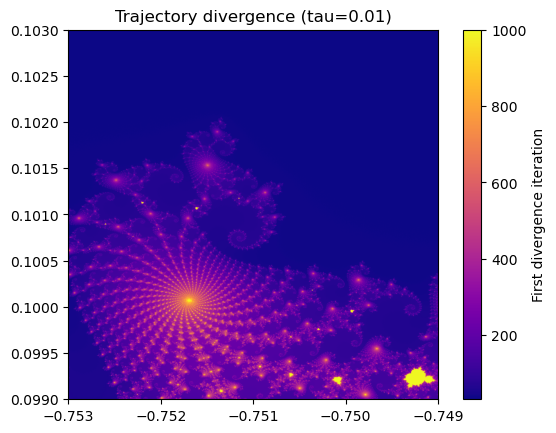

In [8]:
import numpy as np
import matplotlib.pyplot as plt

N, MAX_ITER, TAU = 1024, 1000, 0.01
x = np.linspace(-0.7510, -0.7460, N)
y = np.linspace( 0.0990,  0.1030, N)

C64 = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
C32 = C64.astype(np.complex64)

z32 = np.zeros_like(C32)
z64 = np.zeros_like(C64)
diverge = np.full((N, N), MAX_ITER, dtype=np.int32)
active = np.ones((N, N), dtype=bool)

for k in range(MAX_ITER):
    if not active.any():
        break
    z32[active] = z32[active]**2 + C32[active]
    z64[active] = z64[active]**2 + C64[active]
    diff = (np.abs(z32.real.astype(np.float64) - z64.real)
            + np.abs(z32.imag.astype(np.float64) - z64.imag))
    newly = active & (diff > TAU)
    diverge[newly] = k
    active[newly] = False

frac = np.sum(diverge < MAX_ITER) / diverge.size
print(f"Fraction diverged: {frac:.4f}")

plt.imshow(diverge.T, cmap='plasma', origin='upper', extent=[-0.7530, -0.7490, 0.0990, 0.1030])
plt.colorbar(label='First divergence iteration')
plt.title(f'Trajectory divergence (tau={TAU})')
plt.show()

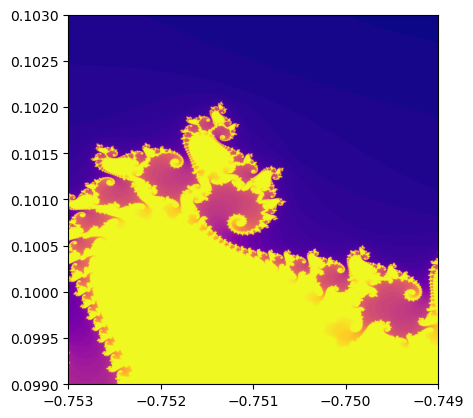

In [11]:
from numba import njit, complex64, prange
import numpy as np

@njit(parallel=True, fastmath=True)
def generate_set(resolution:int = 2048):
    x_region = np.linspace(-0.7510, -0.7460, resolution)
    y_region = np.linspace(0.0990,  0.1030, resolution)
    grid = np.zeros((resolution, resolution))
    for i in prange(0, resolution):
        for j in range(0, resolution):
            c = complex64(x_region[i] + 1j*y_region[j])
            z = complex64(0j)
            for k in range(0, 100):
                z = z**2 + c
                if z.real*z.real + z.imag*z.imag > 4.0: 
                    n = k
                    break
                else: n = 100
            grid[i][j] = n
    return grid

grid = generate_set()
plt.imshow(grid, cmap='plasma', origin='upper', extent=[-0.7530, -0.7490, 0.0990, 0.1030])